In [85]:

import pandas as pd
import time


In [86]:
import requests

def get_specific_event_options(event_ticker):
    base_url = "https://api.elections.kalshi.com/trade-api/v2"
    
    # We query the 'markets' endpoint but filter by the specific event
    params = {
        "event_ticker": event_ticker,
        "status": "settled" 
    }

    resp = requests.get(f"{base_url}/markets", params=params)
    
    # If not in live, check historical
    if not resp.ok or not resp.json().get('markets'):
        resp = requests.get(f"{base_url}/historical/markets", params=params)

    markets = resp.json().get('markets', [])
    
    print(f"--- Options for {event_ticker} ---")
    for m in markets:
        print(f"Ticker: {m['ticker']} | Title: {m['title']}")

# Example: If you only want the 2025 NYC Mayor Party outcome options
get_specific_event_options("KXMAYORNYCPARTY-25")

--- Options for KXMAYORNYCPARTY-25 ---
Ticker: KXMAYORNYCPARTY-25-AC | Title: Will a representative of the Andrew Cuomo party win the NYC Mayor race in 2025?
Ticker: KXMAYORNYCPARTY-25-JWAL | Title: Will a representative of the Jim Walden party win the NYC Mayor race in 2025?
Ticker: KXMAYORNYCPARTY-25-EADA | Title: Will a representative of the Eric Adams party win the NYC Mayor race in 2025?
Ticker: KXMAYORNYCPARTY-25-R | Title: Will a representative of the Republican party win the NYC Mayor race in 2025?
Ticker: KXMAYORNYCPARTY-25-D | Title: Will a representative of the Democratic party win the NYC Mayor race in 2025?


In [ ]:

def get_total_history(start_ts, end_ts, period_interval=60, query_times=None):
    import requests

    # 1. API Setup
    series = "KXMAYORNYCPARTY"
    market = "KXMAYORNYCPARTY-25-R"
    base_url = "https://api.elections.kalshi.com/trade-api/v2"
    live_url = f"{base_url}/series/{series}/markets/{market}/candlesticks"
    historical_url = f"{base_url}/historical/markets/{market}/candlesticks"

    output_columns = [
        "date",
        "price.close_dollars",        # traded close at interval (exact market price)
        "yes_bid.close_dollars",      # bid quote close
        "yes_bid.high_dollars",
        "yes_bid.low_dollars",
        "volume",
        "open_interest",
    ]

    # Kalshi API hard limit is 5000 candles/request; stay safely below
    max_candles_per_request = 4500
    candle_seconds = period_interval * 60
    chunk_span_seconds = (max_candles_per_request - 1) * candle_seconds

    all_points = []
    prefer_historical = False

    print("--- Starting Full Data Extraction ---")

    chunk_start = start_ts
    chunk_idx = 1
    while chunk_start <= end_ts:
        chunk_end = min(chunk_start + chunk_span_seconds, end_ts)
        cursor = None

        print(f"Chunk {chunk_idx}: {chunk_start} -> {chunk_end}")

        while True:
            params = {
                "start_ts": chunk_start,
                "end_ts": chunk_end,
                "period_interval": period_interval,
            }
            if cursor:
                params["cursor"] = cursor

            primary_url = historical_url if prefer_historical else live_url
            fallback_url = live_url if prefer_historical else historical_url

            response = requests.get(primary_url, params=params)

            # Auto-fallback between live and historical candlestick endpoints
            if response.status_code == 404 or "not_found" in response.text:
                response_fallback = requests.get(fallback_url, params=params)
                if response_fallback.status_code == 200:
                    response = response_fallback
                    prefer_historical = fallback_url == historical_url
                    print("Switched endpoint mode:", "historical" if prefer_historical else "live")

            if response.status_code != 200:
                print(f"Error on chunk {chunk_idx}: {response.text}")
                break

            data = response.json()
            batch = data.get("candlesticks", [])
            all_points.extend(batch)
            print(f"Captured {len(all_points)} total data points...")

            cursor = data.get("cursor")
            if not cursor or not batch:
                break

            time.sleep(0.1)

        # Move to next non-overlapping chunk boundary
        chunk_start = chunk_end + candle_seconds
        chunk_idx += 1

    # 5. Process into a clean table
    if not all_points:
        print("No candlestick data returned for the selected window/interval.")
        return pd.DataFrame(columns=output_columns)

    df = pd.json_normalize(all_points)

    # Normalize historical-vs-live schema differences
    if "yes_bid.close" in df.columns and "yes_bid.close_dollars" not in df.columns:
        df["yes_bid.close_dollars"] = df["yes_bid.close"]
    if "yes_bid.high" in df.columns and "yes_bid.high_dollars" not in df.columns:
        df["yes_bid.high_dollars"] = df["yes_bid.high"]
    if "yes_bid.low" in df.columns and "yes_bid.low_dollars" not in df.columns:
        df["yes_bid.low_dollars"] = df["yes_bid.low"]

    if "price.close" in df.columns and "price.close_dollars" not in df.columns:
        df["price.close_dollars"] = df["price.close"]

    if "volume_fp" in df.columns and "volume" not in df.columns:
        df["volume"] = df["volume_fp"]
    if "open_interest_fp" in df.columns and "open_interest" not in df.columns:
        df["open_interest"] = df["open_interest_fp"]

    # Handle possible timestamp field names
    ts_candidates = ["end_period_ts", "end_ts", "end_time", "close_time"]
    ts_col = next((col for col in ts_candidates if col in df.columns), None)

    if ts_col is None:
        print(f"No supported timestamp column found. Available columns: {list(df.columns)}")
        return pd.DataFrame(columns=output_columns)

    df["date"] = pd.to_datetime(df[ts_col], unit="s")

    if query_times:
        # Keep rows that match user-selected intraday times, e.g. ["10:00", "14:00", "16:00"]
        selected_times = set(query_times)
        df = df[df["date"].dt.strftime("%H:%M").isin(selected_times)]

    # Ensure expected columns always exist, even if API omits some
    for col in output_columns:
        if col not in df.columns:
            df[col] = pd.NA

    # Remove duplicates if any chunk boundaries overlap in upstream data
    df = df.sort_values("date").drop_duplicates(subset=["date"], keep="last")

    return df[output_columns]

# Range: July 1st, 2025 to Dec 31st, 2025
start_ts = 1730419200
end_ts = 1767225600

# Edit this list whenever you want different query times (24-hour format)
query_times = None

# Run it (60-minute candles so specific times can be filtered)
df_full = get_total_history(start_ts, end_ts, period_interval=60, query_times=query_times)

# Show the results
print(f"\nUsing time filters: {query_times}")
print("\nFirst 5 rows:")
print(df_full.head())
print("\nLast 5 rows:")
print(df_full.tail())

# Save to CSV so you can see every single point in Excel
df_full.to_csv("nyc_mayor_complete_2025.csv", index=False)

--- Starting Full Data Extraction ---
Chunk 1: 1730419200 -> 1746615600
Switched endpoint mode: historical
Captured 0 total data points...
Chunk 2: 1746619200 -> 1762815600
Captured 3077 total data points...
Chunk 3: 1762819200 -> 1767225600
Captured 3077 total data points...

Using time filters: None

First 5 rows:
                 date price.close_dollars yes_bid.close_dollars  \
0 2025-06-25 04:00:00              0.0600                0.0100   
1 2025-06-25 05:00:00              0.0500                0.0400   
2 2025-06-25 06:00:00              0.0500                0.0400   
3 2025-06-25 07:00:00              0.0500                0.0400   
4 2025-06-25 08:00:00                 NaN                0.0400   

  yes_bid.high_dollars yes_bid.low_dollars    volume open_interest  
0               0.0100              0.0100   1927.00       1927.00  
1               0.0400              0.0100  77586.00      79493.00  
2               0.0500              0.0400  13392.00      91254.00  
3  

In [88]:
df_full

,date,price.close_dollars,yes_bid.close_dollars,yes_bid.high_dollars,yes_bid.low_dollars,volume,open_interest
0,2025-06-25 04:00:00,0.0600,0.0100,0.0100,0.0100,1927.00,1927.00
1,2025-06-25 05:00:00,0.0500,0.0400,0.0400,0.0100,77586.00,79493.00
2,2025-06-25 06:00:00,0.0500,0.0400,0.0500,0.0400,13392.00,91254.00
3,2025-06-25 07:00:00,0.0500,0.0400,0.0400,0.0400,746.00,92000.00
4,2025-06-25 08:00:00,NaN,0.0400,0.0400,0.0400,0.00,92000.00
...,...,...,...,...,...,...,...
3072,2025-11-07 00:00:00,0.0100,0.0000,0.0000,0.0000,7338.00,30271070.00
3073,2025-11-07 01:00:00,0.0100,0.0000,0.0000,0.0000,92.00,30271150.00
3074,2025-11-07 02:00:00,0.0100,0.0000,0.0000,0.0000,505.00,30271150.00
3075,2025-11-07 03:00:00,0.0100,0.0000,0.0000,0.0000,1001.00,30271150.00


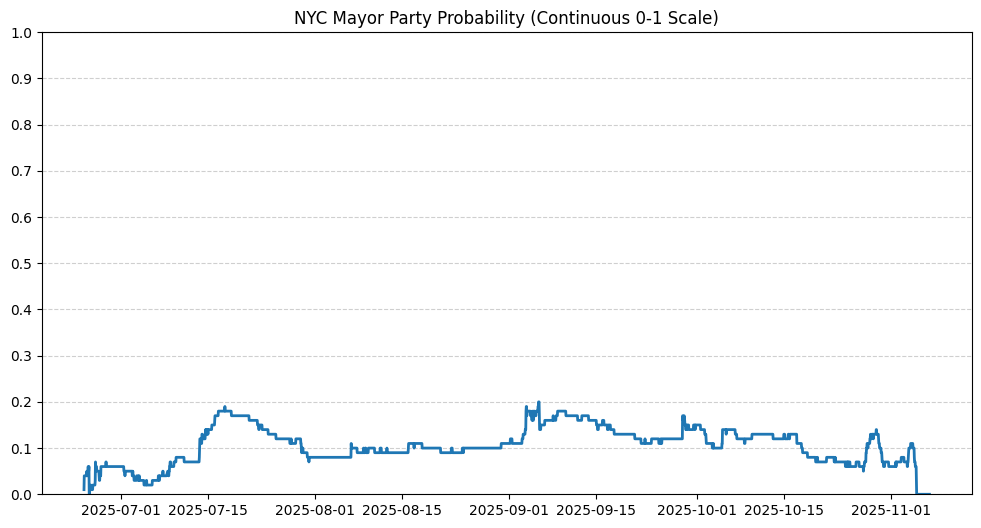

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure data is numeric and sorted (CRITICAL)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date')
df_full['yes_bid.close_dollars'] = pd.to_numeric(df_full['yes_bid.close_dollars'])

plt.figure(figsize=(12, 6))

# 2. Plot the line
plt.plot(df_full['date'], df_full['yes_bid.close_dollars'], linewidth=2)

# 3. SET THE BOUNDS (This makes the axis continuous 0-1)
plt.ylim(0, 1.0)

# 4. SET THE TICKS (This places the numbers)
plt.yticks(np.arange(0, 1.1, 0.1))

# 5. Add Grid for better visibility
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.title("NYC Mayor Party Probability (Continuous 0-1 Scale)")
plt.show()

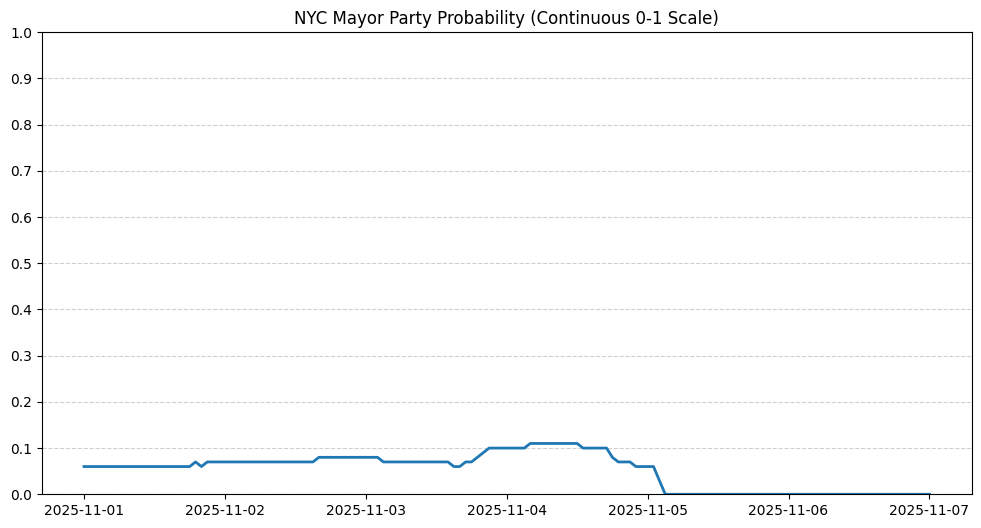

In [90]:
# zoom inimport matplotlib.pyplot as plt
import numpy as np



# 1. Ensure data is numeric and sorted (CRITICAL)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date')
df_full['yes_bid.close_dollars'] = pd.to_numeric(df_full['yes_bid.close_dollars'])

# start_date in "YYYY-MM-DD" format
start_date = "2025-11-01"
end_date = "2025-11-07"
mask = (df_full['date'] >= start_date) & (df_full['date'] <= end_date)
df_temp = df_full.loc[mask]

plt.figure(figsize=(12, 6))

# 2. Plot the line
plt.plot(df_temp['date'], df_temp['yes_bid.close_dollars'], linewidth=2)

# 3. SET THE BOUNDS (This makes the axis continuous 0-1)
plt.ylim(0, 1.0)

# 4. SET THE TICKS (This places the numbers)
plt.yticks(np.arange(0, 1.1, 0.1))

# 5. Add Grid for better visibility
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.title("NYC Mayor Party Probability (Continuous 0-1 Scale)")
plt.show()


In [91]:
# 06-23 to 06-26
# 11-01 to 11-07

In [ ]:
#mamdani = df_full
#cuomo = df_full
sliwa = df_full

In [ ]:
#mamdani.to_csv("mamdani_data.csv", index=False)
#cuomo.to_csv("cuomo_data.csv", index=False)
sliwa.to_csv("sliwa_data.csv", index=False)

In [94]:
df_full

,date,price.close_dollars,yes_bid.close_dollars,yes_bid.high_dollars,yes_bid.low_dollars,volume,open_interest
0,2025-06-25 04:00:00,0.0600,0.01,0.0100,0.0100,1927.00,1927.00
1,2025-06-25 05:00:00,0.0500,0.04,0.0400,0.0100,77586.00,79493.00
2,2025-06-25 06:00:00,0.0500,0.04,0.0500,0.0400,13392.00,91254.00
3,2025-06-25 07:00:00,0.0500,0.04,0.0400,0.0400,746.00,92000.00
4,2025-06-25 08:00:00,NaN,0.04,0.0400,0.0400,0.00,92000.00
...,...,...,...,...,...,...,...
3072,2025-11-07 00:00:00,0.0100,0.00,0.0000,0.0000,7338.00,30271070.00
3073,2025-11-07 01:00:00,0.0100,0.00,0.0000,0.0000,92.00,30271150.00
3074,2025-11-07 02:00:00,0.0100,0.00,0.0000,0.0000,505.00,30271150.00
3075,2025-11-07 03:00:00,0.0100,0.00,0.0000,0.0000,1001.00,30271150.00


NameError: name 'sliwa' is not defined

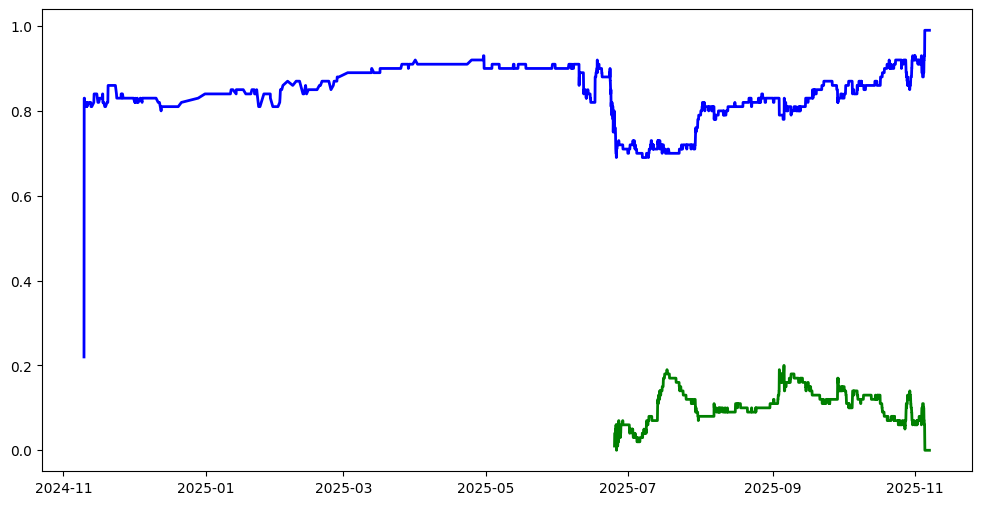

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure data is numeric and sorted (CRITICAL)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date')
df_full['yes_bid.close_dollars'] = pd.to_numeric(df_full['yes_bid.close_dollars'])

plt.figure(figsize=(12, 6))

# 2. Plot the line
plt.plot(mamdani[:-1]['date'], mamdani[:-1]['yes_bid.close_dollars'], color='blue', label='Mamdani', linewidth=2)
plt.plot(cuomo[:-1]['date'], cuomo[:-1]['yes_bid.close_dollars'], color='green', label='Cuomo', linewidth=2)
plt.plot(sliwa[:-1]['date'], sliwa[:-1]['yes_bid.close_dollars'], color='red', label='Sliwa', linewidth=2)

# Optional: Add a legend so people know which color is which
plt.legend()
# 3. SET THE BOUNDS (This makes the axis continuous 0-1)
plt.ylim(0, 1.0)

# 4. SET THE TICKS (This places the numbers)
plt.yticks(np.arange(0, 1.1, 0.1))

# 5. Add Grid for better visibility
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.title("NYC Mayor Party Probability (Continuous 0-1 Scale)")
plt.show()

NameError: name 'sliwa' is not defined

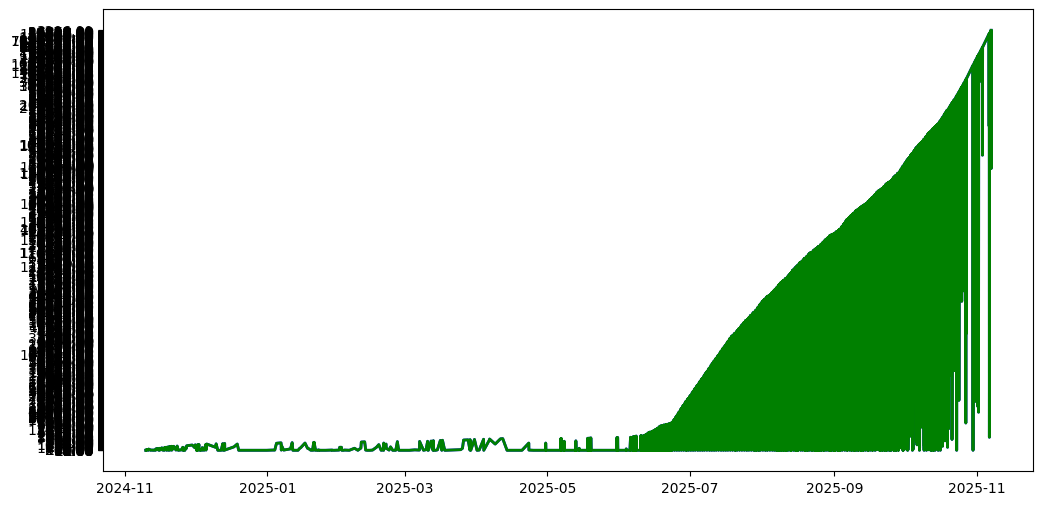

In [ ]:

# 1. Ensure data is numeric and sorted (CRITICAL)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date')
df_full['yes_bid.close_dollars'] = pd.to_numeric(df_full['yes_bid.close_dollars'])

plt.figure(figsize=(12, 6))

# 2. Plot the line
plt.plot(mamdani['date'], mamdani['volume'], color='blue', label='Mamdani', linewidth=2)
plt.plot(cuomo['date'], cuomo['volume'], color='green', label='Cuomo', linewidth=2)
plt.plot(sliwa['date'], sliwa['volume'], color='red', label='Sliwa', linewidth=2)

# Optional: Add a legend so people know which color is which
plt.legend()


# 5. Add Grid for better visibility
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.title("NYC Mayor Party Volume ")
plt.show()

In [ ]:

# 1. Ensure data is numeric and sorted (CRITICAL)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date')
mamdani['yes_bid.high_dollars'] = pd.to_numeric(mamdani['yes_bid.high_dollars'])
mamdani['yes_bid.low_dollars'] = pd.to_numeric(mamdani['yes_bid.low_dollars'])

cuomo['yes_bid.high_dollars'] = pd.to_numeric(cuomo['yes_bid.high_dollars'])
cuomo['yes_bid.low_dollars'] = pd.to_numeric(cuomo['yes_bid.low_dollars'])

sliwa['yes_bid.high_dollars'] = pd.to_numeric(sliwa['yes_bid.high_dollars'])
sliwa['yes_bid.low_dollars'] = pd.to_numeric(sliwa['yes_bid.low_dollars'])

plt.figure(figsize=(12, 6))

mamdami_spread = mamdani['yes_bid.high_dollars'] - mamdani['yes_bid.low_dollars']
cuomo_spread = cuomo['yes_bid.high_dollars'] - cuomo['yes_bid.low_dollars']
sliwa_spread = sliwa['yes_bid.high_dollars'] - sliwa['yes_bid.low_dollars']

# 2. Plot the xd
plt.plot(mamdani[:-1]['date'], mamdami_spread[:-1], color='blue', label='Mamdani', linewidth=2)
plt.plot(cuomo[:-1]['date'], cuomo_spread[:-1], color='green', label='Cuomo', linewidth=2)
plt.plot(sliwa[:-1]['date'], sliwa_spread[:-1], color='red', label='Sliwa', linewidth=2)

# Optional: Add a legend so people know which color is which
plt.legend()


# 5. Add Grid for better visibility
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.title("NYC Mayor Party High-Low Spread ")
plt.show()

NameError: name 'mamdani' is not defined

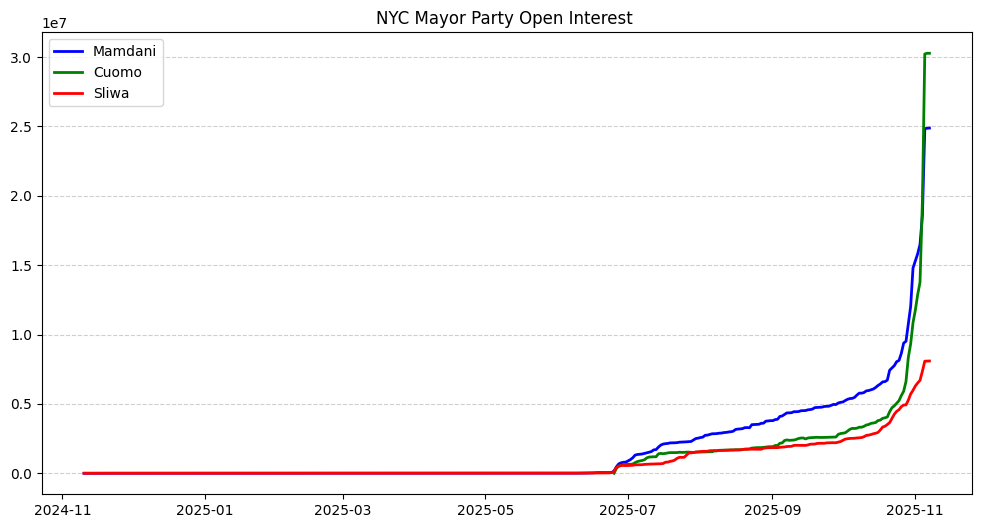

In [ ]:

# 1. Ensure data is numeric and sorted (CRITICAL)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date')
df_full['yes_bid.close_dollars'] = pd.to_numeric(df_full['yes_bid.close_dollars'])

plt.figure(figsize=(12, 6))

# 2. Plot the line
plt.plot(mamdani['date'], mamdani['open_interest'], color='blue', label='Mamdani', linewidth=2)
plt.plot(cuomo['date'], cuomo['open_interest'], color='green', label='Cuomo', linewidth=2)
plt.plot(sliwa['date'], sliwa['open_interest'], color='red', label='Sliwa', linewidth=2)

# Optional: Add a legend so people know which color is which
plt.legend()


# 5. Add Grid for better visibility
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.title("NYC Mayor Party Open Interest ")
plt.show()

In [ ]:
mamdani.describe()

,date,yes_bid.close_dollars,yes_bid.high_dollars,yes_bid.low_dollars,volume,open_interest
count,310,310.000000,310.000000,310.000000,3.100000e+02,3.100000e+02
mean,2025-05-24 03:59:25,0.840516,0.848774,0.831935,1.540020e+05,2.128151e+06
min,2024-11-10 05:00:00,0.000000,0.690000,0.000000,0.000000e+00,3.000000e+00
25%,2025-02-21 11:00:00,0.810000,0.820000,0.810000,2.000000e+00,3.883000e+03
50%,2025-06-05 16:00:00,0.850000,0.850000,0.840000,8.210000e+02,7.523500e+03
75%,2025-08-21 22:00:00,0.900000,0.900000,0.890000,8.103725e+04,3.292234e+06
max,2025-11-07 05:00:00,0.990000,0.990000,0.990000,1.375066e+07,2.487994e+07
std,NaN,0.077399,0.059933,0.089295,8.720900e+05,3.748382e+06


In [ ]:
print(mamdani.describe().to_latex(index=True, caption="Descriptive Statistics Mamdami Kalshi Data", label="tab:desc_stats"))

\begin{table}
\caption{Descriptive Statistics Mamdami Kalshi Data}
\label{tab:desc_stats}
\begin{tabular}{llrrrrr}
\toprule
 & date & yes_bid.close_dollars & yes_bid.high_dollars & yes_bid.low_dollars & volume & open_interest \\
\midrule
count & 310 & 310.000000 & 310.000000 & 310.000000 & 310.000000 & 310.000000 \\
mean & 2025-05-24 03:59:25 & 0.840516 & 0.848774 & 0.831935 & 154001.964516 & 2128151.212903 \\
min & 2024-11-10 05:00:00 & 0.000000 & 0.690000 & 0.000000 & 0.000000 & 3.000000 \\
25% & 2025-02-21 11:00:00 & 0.810000 & 0.820000 & 0.810000 & 2.000000 & 3883.000000 \\
50% & 2025-06-05 16:00:00 & 0.850000 & 0.850000 & 0.840000 & 821.000000 & 7523.500000 \\
75% & 2025-08-21 22:00:00 & 0.900000 & 0.900000 & 0.890000 & 81037.250000 & 3292234.500000 \\
max & 2025-11-07 05:00:00 & 0.990000 & 0.990000 & 0.990000 & 13750662.000000 & 24879936.000000 \\
std & NaN & 0.077399 & 0.059933 & 0.089295 & 872090.026342 & 3748381.597428 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
print(cuomo.describe().to_latex(index=True, caption="Descriptive Statistics Cuomo Kalshi Data", label="tab:desc_stats"))

\begin{table}
\caption{Descriptive Statistics Cuomo Kalshi Data}
\label{tab:desc_stats}
\begin{tabular}{llrrrrr}
\toprule
 & date & yes_bid.close_dollars & yes_bid.high_dollars & yes_bid.low_dollars & volume & open_interest \\
\midrule
count & 136 & 136.000000 & 136.000000 & 136.000000 & 136.000000 & 136.000000 \\
mean & 2025-08-31 16:01:45 & 0.104118 & 0.111691 & 0.096985 & 382931.448529 & 3365902.382353 \\
min & 2025-06-25 04:00:00 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 1927.000000 \\
25% & 2025-07-28 22:00:00 & 0.080000 & 0.080000 & 0.070000 & 24215.000000 & 1523850.500000 \\
50% & 2025-08-31 16:00:00 & 0.105000 & 0.110000 & 0.100000 & 61148.000000 & 1918028.000000 \\
75% & 2025-10-04 10:00:00 & 0.130000 & 0.140000 & 0.122500 & 145702.500000 & 3183273.250000 \\
max & 2025-11-07 05:00:00 & 0.180000 & 0.200000 & 0.180000 & 20296152.000000 & 30271150.000000 \\
std & NaN & 0.041356 & 0.040889 & 0.041407 & 1917667.680955 & 4838700.995296 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
print(sliwa.describe().to_latex(index=True, caption="Descriptive Statistics Sliwa Kalshi Data", label="tab:desc_stats"))

\begin{table}
\caption{Descriptive Statistics Sliwa Kalshi Data}
\label{tab:desc_stats}
\begin{tabular}{llrrrrr}
\toprule
 & date & yes_bid.close_dollars & yes_bid.high_dollars & yes_bid.low_dollars & volume & open_interest \\
\midrule
count & 303 & 303.000000 & 303.000000 & 303.000000 & 303.000000 & 303.000000 \\
mean & 2025-05-28 07:50:53 & 0.051617 & 0.053630 & 0.049043 & 37297.953795 & 1005844.973597 \\
min & 2024-11-10 05:00:00 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 396.000000 \\
25% & 2025-02-28 17:00:00 & 0.020000 & 0.020000 & 0.010000 & 1.000000 & 6199.000000 \\
50% & 2025-06-09 04:00:00 & 0.060000 & 0.060000 & 0.060000 & 454.000000 & 8313.000000 \\
75% & 2025-08-23 16:00:00 & 0.090000 & 0.100000 & 0.090000 & 22103.500000 & 1736239.000000 \\
max & 2025-11-07 05:00:00 & 0.130000 & 0.130000 & 0.130000 & 1167458.000000 & 8091996.000000 \\
std & NaN & 0.039664 & 0.040075 & 0.038910 & 110506.562153 & 1552369.886271 \\
\bottomrule
\end{tabular}
\end{table}

